# Clasificación de Razas de Perros y Gatos con CNN (Oxford-IIIT Pet Dataset)

## Informe técnico — Proyecto de Redes Neuronales Convolucionales

**Objetivo:** entrenar un clasificador capaz de reconocer 37 razas de perros y gatos a partir de imágenes, alcanzando una *accuracy* en el conjunto de test de al menos **85%**, sin evidencias de *overfitting* ni de *underfitting* en el modelo final seleccionado.

**Dataset:** [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) — 37 razas de perros y gatos, ~200 imágenes por clase, con alta variabilidad de escala, pose, iluminación, fondo y encuadre. Se accede a través de `tensorflow_datasets` (`oxford_iiit_pet`).

### Estructura del notebook

| Fase | Contenido |
|---|---|
| **Fase 1** | Exploración de datos (EDA), preparación (pipelines `tf.data`), infraestructura común (utilidades de entrenamiento/evaluación) |
| **Fase 2** | Entrenamiento del modelo: **ResNet18** (CNN residual), arquitectura propuesta implementada desde cero |
| **Fase 3** | Evaluación final, matriz de confusión, análisis visual de errores y despliegue |

### Configuración global

```
SEED        = 42
IMG_SIZE    = 160
BATCH_SIZE  = 32
NUM_CLASSES = 37
EPOCHS      = 40
split = ['train[:80%]', 'train[80%:90%]', 'train[90%:]']
```

## Introducción a la funcionalidad y arquitectura de ResNet18

La red residual ResNet18 constituye la base del sistema propuesto para la clasificación de razas de perros y gatos. Su principal objetivo es aprender representaciones visuales jerárquicas a partir de imágenes, extrayendo características de bajo nivel (bordes, texturas, contrastes), intermedias (formas, patrones regionales) y alto nivel (rasgos distintivos de cada raza). En este proyecto, la red se adapta al problema de clasificación multiclase sobre el dataset Oxford-IIIT Pet, donde cada imagen debe asignarse a una de 37 categorías.

La arquitectura ResNet18 se caracteriza por la introducción de conexiones residuales, también conocidas como *skip connections*. Estas conexiones permiten que la entrada de una capa se sume a la salida de varias capas convolucionales, facilitando el flujo del gradiente durante el entrenamiento y evitando la degradación que suele aparecer en redes muy profundas. En lugar de aprender una transformación completa de forma directa, cada bloque residual aprende un residuo: $F(x) = H(x) - x$, y la salida final se calcula como $H(x) = F(x) + x$. Este diseño hace que la red pueda profundizarse sin perder información útil ni saturar el aprendizaje.

En términos de estructura, ResNet18 está diseñada en cuatro etapas principales de bloques residuales, cada una con una progresión espacial de reducción de resolución y aumento de profundidad de canales. La red inicia con una capa de convolución y normalización, seguida de bloques residuales que preservan la información mediante conexiones de acceso directo. Posteriormente, se aplica una capa de pooling global y una cabeza de clasificación con una capa densa final, adaptada a 37 clases.

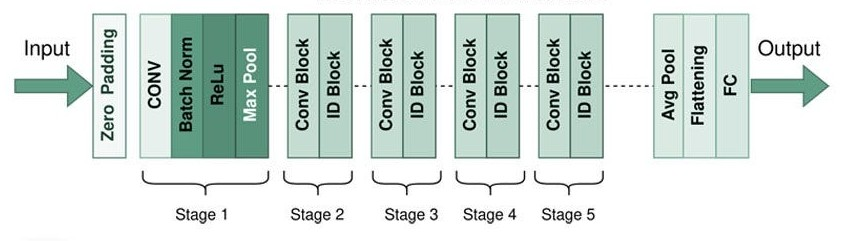

ResNet-18 consta de 18 capas con parámetros que se pueden aprender. Se compone de una serie de capas convolucionales, seguidas de funciones de activación y normalización por lotes, que culminan en capas completamente conectadas para la clasificación.

En este caso, la red se implementa desde cero y se entrena sobre imágenes redimensionadas a 160x160 píxeles, con datos normalizados en el rango $[0,1]$. Además, se emplea augmentación de datos para mejorar la generalización y se usa un esquema de entrenamiento con validación y callbacks de early stopping, reducción de tasa de aprendizaje y checkpointing para conservar el mejor modelo.

La elección de ResNet18 resulta especialmente adecuada para este problema porque equilibra capacidad representacional y eficiencia computacional: es suficientemente profunda para capturar patrones complejos de las razas, pero conserva una implementación manejable y un entrenamiento estable gracias a sus conexiones residuales.

In [28]:
# Ejecutar una vez al abrir el notebook, antes de importar TensorFlow.
# Esta celda prepara el entorno base para que el proyecto funcione en Windows, macOS y Linux.
# La idea es detectar el sistema operativo y instalar la versión compatible de TensorFlow
# con GPU o con la ruta alternativa de CPU cuando no haya aceleración disponible.
import platform
import subprocess
import sys

# El proyecto se desarrolla con versiones de Python compatibles con TensorFlow 2.16.
if not (sys.version_info >= (3, 10) and sys.version_info < (3, 13)):
    raise RuntimeError("Este proyecto requiere Python 3.10, 3.11 o 3.12.")

system = platform.system()
machine = platform.machine().lower()
print(f"Sistema operativo detectado: {system} ({machine})")

# Librerías comunes necesarias para EDA, visualización, métricas y carga del dataset.
requirements = [
    "ipykernel",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tensorflow-datasets==4.9.4",
    "tensorflow-metadata==1.15.0",
]

if system == "Darwin":
    # En macOS, la aceleración GPU depende de Apple Silicon (M1/M2/M3).
    # En equipos Intel, TensorFlow puede ejecutarse en CPU pero sin Metal.
    if machine not in {"arm64", "aarch64"}:
        raise RuntimeError(
            "La aceleración GPU de TensorFlow en macOS requiere Apple Silicon (arm64). "
            "En Intel, usa CPU o un entorno con GPU compatible."
        )
    requirements.extend([
        "tensorflow-macos==2.16.2",
        "tensorflow-metal==1.1.0",
    ])

elif system == "Linux":
    # En Linux, la ruta más común para entrenar con rapidez es TensorFlow con CUDA.
    requirements.append("tensorflow[and-cuda]==2.16.1")

elif system == "Windows":
    # En Windows, TensorFlow se instala con la versión estándar de pip y requiere
    # un sistema con drivers NVIDIA compatibles y la pila CUDA/cuDNN instalada.
    requirements.append("tensorflow")
    print("Windows detectado: asegúrate de tener drivers NVIDIA y CUDA/cuDNN compatibles.")

else:
    raise RuntimeError(f"Sistema operativo no compatible: {system}")

# Instalación final de dependencias del entorno.
subprocess.check_call([sys.executable, "-m", "pip", "install", *requirements])
print(f"Dependencias listas para {system}. Reinicia el kernel si TensorFlow ya estaba importado.")

Sistema operativo detectado: Darwin (arm64)
Dependencias listas para Darwin. Reinicia el kernel si TensorFlow ya estaba importado.


In [14]:
# Este bloque inicializa las bibliotecas principales y define los parámetros globales del experimento.
# Mantener una semilla fija es clave para que los resultados sean reproducibles en cada ejecución.
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks, applications, optimizers
from sklearn.metrics import confusion_matrix, classification_report

# --- Configuración global reproducible ---
# Estos valores controlan el tamaño de las imágenes, el batch, el número de clases y la duración total del entrenamiento.
SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 32
NUM_CLASSES = 37
EPOCHS = 40

# Establecemos semillas para garantizar reproducibilidad en NumPy, Python y TensorFlow.
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorFlow usa AUTOTUNE para optimizar paralelismo en carga y preprocesamiento de datos.
AUTOTUNE = tf.data.AUTOTUNE

# --- Configuración de TensorFlow según disponibilidad de GPU ---
# También funciona en CPU si no hay GPU disponible; el entrenamiento será más lento, pero no fallará.
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs disponibles: {len(gpus)}")

if gpus:
    # Se activa crecimiento dinámico de memoria para evitar que TensorFlow consuma toda la VRAM de golpe.
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_soft_device_placement(True)

    print(f"Usando GPU: {gpus[0].name}")

else:
    print(
        "No se detectó GPU. El notebook continuará en CPU. Para rendimiento óptimo, "
        "usa una GPU compatible con TensorFlow en Windows, macOS (Apple Silicon) o Linux."
    )

TensorFlow: 2.16.2
GPUs disponibles: 1
Usando GPU: /physical_device:GPU:0


## Fase 1 — Exploración, Preparación de Datos e Infraestructura

Se carga el dataset `oxford_iiit_pet` desde `tensorflow_datasets`, usando la etiqueta `label` (37 razas). El dataset oficial solo trae particiones `train`/`test`; como se pide trabajar únicamente sobre `train` con una partición 80/10/10, se generan los splits `train[:80%]`, `train[80%:90%]` y `train[90%:]` para train/val/test respectivamente.


In [15]:
# Cargamos el dataset Oxford-IIIT Pet desde TensorFlow Datasets.
# Se usa la partición train con una separación 80/10/10 para entrenamiento, validación y test.
# Esto evita mezclar las particiones oficiales y crea una división más controlada para la evaluación final.
split = ["train[:80%]", "train[80%:90%]", "train[90%:]"]
DATA_DIR = os.path.join(os.getcwd(), "tensorflow_datasets")
os.makedirs(DATA_DIR, exist_ok=True)

(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=split,
    with_info=True,
    as_supervised=True,
    data_dir=DATA_DIR,
)

class_names = ds_info.features["label"].names
print(f"Número de clases: {ds_info.features['label'].num_classes}")
print(f"Ejemplos train: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")

print(f"Ejemplos val:   {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Dataset local: {DATA_DIR}")
print(f"Ejemplos test:  {tf.data.experimental.cardinality(ds_test_raw).numpy()}")

Número de clases: 37
Ejemplos train: 2944
Ejemplos val:   368
Dataset local: /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets
Ejemplos test:  368


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-11 12:09:59.516195: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


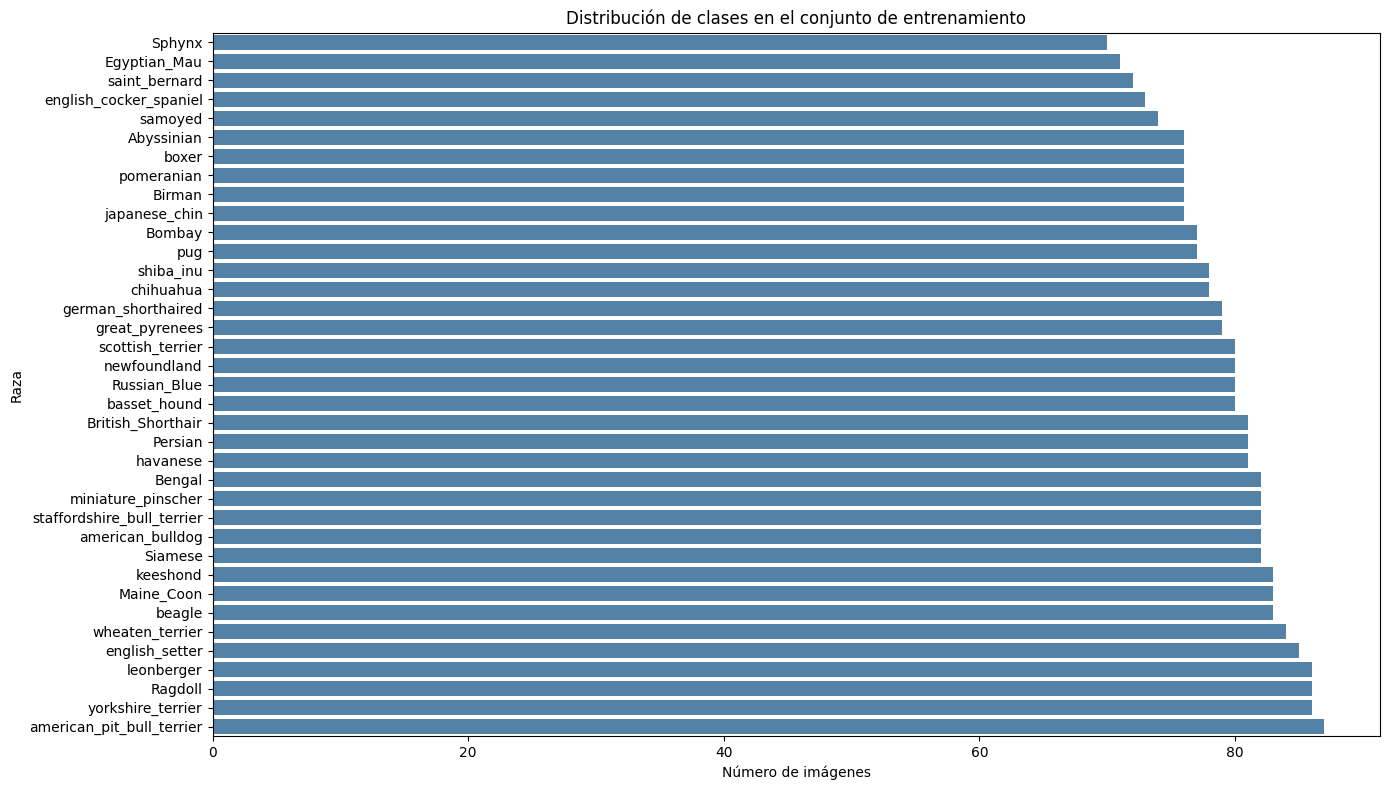

Mínimo por clase: 70  |  Máximo por clase: 87  |  Media: 79.6
Ratio desbalance (max/min): 1.24


In [16]:
# --- Distribución de clases (balance del dataset) ---
# Es importante comprobar si todas las razas tienen una cantidad similar de imágenes.
# Un conjunto desequilibrado puede provocar sesgos en la red y empeorar la precisión de clases minoritarias.
train_labels = np.array([label.numpy() for _, label in ds_train_raw])
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

df_counts = pd.DataFrame({"raza": class_names, "n_train": counts}).sort_values("n_train")

plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, y="raza", x="n_train", color="steelblue")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Número de imágenes")
plt.ylabel("Raza")
plt.tight_layout()
plt.show()

print(f"Mínimo por clase: {counts.min()}  |  Máximo por clase: {counts.max()}  |  Media: {counts.mean():.1f}")

print(f"Ratio desbalance (max/min): {counts.max() / counts.min():.2f}")

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-11 12:10:01.280668: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


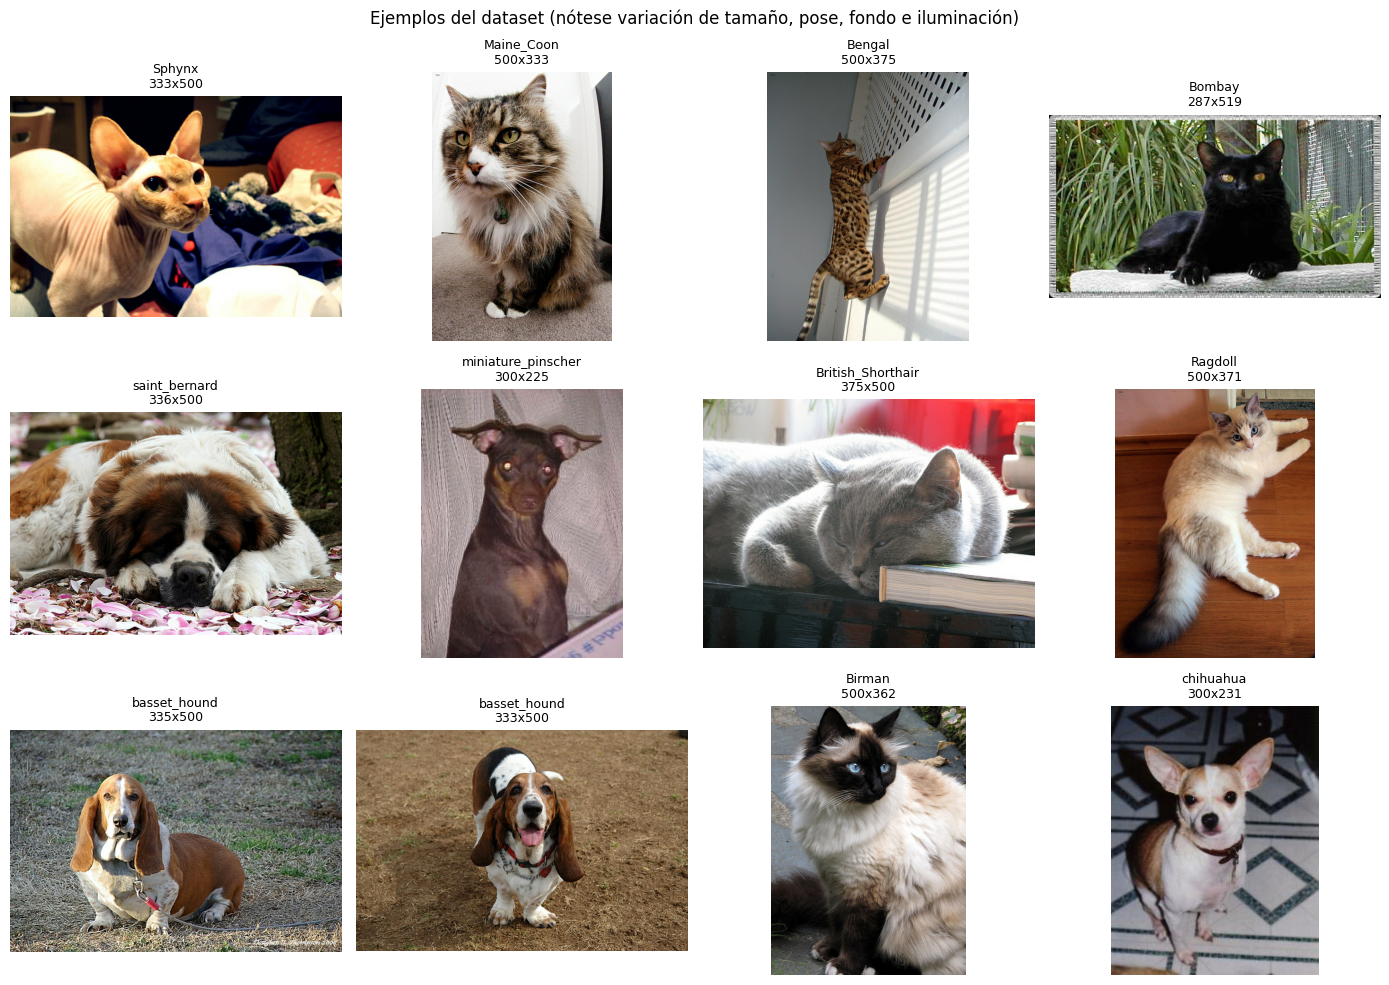

Alto - media/min/max: 384.27 150 1920
Ancho - media/min/max: 434.1166666666667 119 2560


2026-09-11 12:10:01.582956: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
# --- Ejemplos representativos y variabilidad de tamaños/aspect ratio ---
# Este análisis visual ayuda a entender la complejidad del problema antes de entrenar.
# Las imágenes presentan cambios de tamaño, fondo, pose y encuadre, por lo que la red debe aprender invariancias.
plt.figure(figsize=(14, 10))
for i, (image, label) in enumerate(ds_train_raw.shuffle(1000, seed=SEED).take(12)):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{class_names[label.numpy()]}\n{image.shape[0]}x{image.shape[1]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset (nótese variación de tamaño, pose, fondo e iluminación)")
plt.tight_layout()
plt.show()

# También calculamos estadísticos simples para confirmar que las dimensiones no son uniformes.
# Esto justifica el redimensionado y la augmentación durante el entrenamiento.
sample_shapes = np.array([image.shape[:2] for image, _ in ds_train_raw.take(300)])

print("Alto - media/min/max:", sample_shapes[:, 0].mean(), sample_shapes[:, 0].min(), sample_shapes[:, 0].max())
print("Ancho - media/min/max:", sample_shapes[:, 1].mean(), sample_shapes[:, 1].min(), sample_shapes[:, 1].max())

### Pipelines `tf.data` y augmentation

Se define una única función de preprocesamiento (`resize` a `IMG_SIZE x IMG_SIZE` + normalización a `[0,1]`) y una capa de *data augmentation* (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) que solo se aplica sobre el split de entrenamiento. Estas capas se ejecutan dentro del grafo (`tf.keras.Sequential`), por lo que solo están activas cuando `training=True`, evitando afectar validación/test.


In [18]:
# Esta sección prepara cada conjunto de datos para ser consumido por la red neuronal.
# Se realiza un redimensionado uniforme a 160x160, la normalización a [0, 1] y, opcionalmente,
# una capa de augmentación para ayudar a la generalización en imágenes con variación visual.

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
    ],
    name="data_augmentation",
)


def make_dataset(ds_raw, shuffle=False, augment=False):
    # map() aplica el preprocesado por cada imagen; luego el batch permite entrenar por lotes.
    ds = ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        # La augmentación solo se activa durante entrenamiento, no en validación ni test.
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


# Se crean los datasets para entrenamiento, validación y test.
# El set de entrenamiento se genera con dos variantes: una con augmentación y otra sin ella.

train_ds_aug = make_dataset(ds_train_raw, shuffle=True, augment=True)
train_ds = make_dataset(ds_train_raw, shuffle=True, augment=False)
val_ds = make_dataset(ds_val_raw)
test_ds = make_dataset(ds_test_raw)

print("Batch de ejemplo:", next(iter(train_ds_aug))[0].shape)

2026-09-11 12:10:02.970464: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


Batch de ejemplo: (32, 160, 160, 3)


2026-09-11 12:10:03.271871: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_27}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2026-09-11 12:10:03.273532: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_27}}]]
	 [[GroupCrossDeviceControlEdges_0/NoOp/_26]] [type.googleapis.com/tensorflow.DerivedStatus='']


In [19]:
# --- Infraestructura común de entrenamiento/evaluación reutilizada en todas las fases ---
# Este bloque centraliza la lógica de entrenamiento para compararar distintos modelos de forma consistente.
# Guarda resultados, plotea curvas de aprendizaje y evita sobreajuste mediante callbacks.
os.makedirs("checkpoints", exist_ok=True)
results = {}  # nombre_modelo -> dict con métricas e historial, para comparación final en Fase 4


def build_callbacks(name, patience=6, lr_patience=3, monitor="val_accuracy", use_reduce_lr=True):
    # EarlyStopping evita entrenar demasiado tiempo si la validación deja de mejorar.
    # ModelCheckpoint conserva el mejor modelo según la métrica elegida.
    cbs = [
        callbacks.EarlyStopping(monitor=monitor, mode="max", patience=patience, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"checkpoints/{name}.keras", monitor=monitor, mode="max", save_best_only=True),
    ]
    if use_reduce_lr:
        # ReduceLROnPlateau baja la tasa de aprendizaje cuando la pérdida se estanca.
        # Solo aplica si el optimizador usa un learning_rate fijo (no un LearningRateSchedule).
        cbs.append(callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=lr_patience, min_lr=1e-6))
    return cbs


def plot_history(history, title):
    # Visualizamos la evolución del entrenamiento para verificar si hay mejora estable o sobreajuste.
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def train_and_evaluate(model, name, train_data, val_data, epochs=EPOCHS, extra_callbacks=None, patience=6, lr_patience=3, use_reduce_lr=True):
    # Reutilizamos la misma rutina para cualquier arquitectura, comparando después sus métricas.
    cbs = build_callbacks(name, patience=patience, lr_patience=lr_patience, use_reduce_lr=use_reduce_lr) + (extra_callbacks or [])
    history = model.fit(train_data, validation_data=val_data, epochs=epochs, callbacks=cbs, verbose=2)
    plot_history(history, name)

    # Evaluamos sobre train, validación y test para conocer la capacidad real de generalización.
    train_loss, train_acc = model.evaluate(train_data, verbose=0)
    val_loss, val_acc = model.evaluate(val_data, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    results[name] = {
        "history": history.history,
        "train_acc": train_acc, "train_loss": train_loss,
        "val_acc": val_acc, "val_loss": val_loss,
        "test_acc": test_acc, "test_loss": test_loss,
        "model": model,
    }
    print(f"\n[{name}] train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  test_acc={test_acc:.3f}  "
          f"gap(train-val)={train_acc - val_acc:.3f}")
    return history

## Fase 2 — Entrenamiento del Modelo: ResNet18 (CNN Residual)

Se entrena una **ResNet18 residual desde cero**: arquitectura con bloques residuales (*skip connections*), implementada manualmente con Keras Functional API (Keras no incluye ResNet18/34 en `keras.applications`, solo variantes ≥50 capas). Las conexiones residuales facilitan el entrenamiento de redes más profundas al mitigar el problema del *vanishing gradient*.


In [ ]:
# --- Modelo 3: ResNet18 (CNN residual) construida desde cero ---
# Se implementa una arquitectura residual con bloques básicos de ResNet, que permiten entrenar redes profundas
# sin degradación del gradiente. Esta parte es central del proyecto porque la capacidad de reconocer razas
# depende de extraer características visuales complejas con varias capas convolucionales apiladas.```
WEIGHT_DECAY = 1e-4  # L2 moderado: 5e-4 en las 18 capas frenaba demasiado el aprendizaje en solo 40 épocas


def conv_bn(x, filters, kernel_size, strides=1, activation="relu"):
    # Cada bloque inicia con una conv2d seguida de batch normalization y activación.
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                       use_bias=False, kernel_initializer="he_normal",
                       kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    if activation:
        x = layers.Activation(activation)(x)
    return x


def basic_residual_block(x, filters, strides=1):
    # Bloque residual básico: se suma la entrada original con la salida del bloque convolucional.
    # Esta conexión de salto permite al modelo aprender un residuo en lugar de una transformación completa.
    shortcut = x
    y = conv_bn(x, filters, 3, strides=strides)
    y = conv_bn(y, filters, 3, strides=1, activation=None)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = conv_bn(shortcut, filters, 1, strides=strides, activation=None)
    out = layers.Add()([shortcut, y])
    return layers.Activation("relu")(out)


def build_resnet18(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    # Se construye la red siguiendo la topología clásica de ResNet18: cuatro etapas residuales.
    inputs = layers.Input(shape=input_shape)
    x = conv_bn(inputs, 64, 7, strides=2)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    # 4 etapas x 2 bloques residuales básicos = 18 capas con peso (ResNet18)
    stage_config = [(64, 1), (128, 2), (256, 2), (512, 2)]
    for filters, first_stride in stage_config:
        x = basic_residual_block(x, filters, strides=first_stride)
        x = basic_residual_block(x, filters, strides=1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)  # dropout moderado: 0.5 sumado al LR bajo casi no dejaba aprender en 40 épocas
    outputs = layers.Dense(num_classes, activation="softmax",
                            kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY))(x)
    return models.Model(inputs, outputs, name="resnet18_scratch")


# LR con warmup (2 épocas) + cosine decay: estabiliza el entrenamiento de redes residuales desde cero.
# LR pico y de arranque subidos significativamente (antes 3e-4->8e-4): con solo 40 épocas disponibles,
# un LR demasiado bajo dejaba la accuracy estancada cerca del azar (~1/37) tras varias épocas.
STEPS_PER_EPOCH = tf.data.experimental.cardinality(train_ds_aug).numpy()
WARMUP_EPOCHS = 2
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=(EPOCHS - WARMUP_EPOCHS) * STEPS_PER_EPOCH,
    alpha=0.01,
    warmup_target=2e-3,
    warmup_steps=WARMUP_EPOCHS * STEPS_PER_EPOCH,
)

def sparse_crossentropy_with_label_smoothing(y_true, y_pred, smoothing=0.1):
    # SparseCategoricalCrossentropy no soporta label_smoothing; se convierte a one-hot para aplicarlo.
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
    return tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred, label_smoothing=smoothing)



resnet18 = build_resnet18()
resnet18.compile(
    optimizer=optimizers.Adam(lr_schedule),
    loss=sparse_crossentropy_with_label_smoothing,
    metrics=["accuracy"],
)
resnet18.summary()

Model: "resnet18_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 40,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 40,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_4[0][0]  

 Total params: 11,205,093 (42.74 MB)

 Trainable params: 11,195,493 (42.71 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 28s - 302ms/step - accuracy: 0.0574 - loss: 4.9157 - val_accuracy: 0.0217 - val_loss: 18.9556
Epoch 2/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 15s - 167ms/step - accuracy: 0.0880 - loss: 4.5514 - val_accuracy: 0.0652 - val_loss: 7.0560
Epoch 3/40


...

92/92 - 13s - 138ms/step - accuracy: 0.9647 - loss: 1.4625 - val_accuracy: 0.4918 - val_loss: 2.6879
Epoch 39/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 13s - 138ms/step - accuracy: 0.9643 - loss: 1.4601 - val_accuracy: 0.4973 - val_loss: 2.6921
Epoch 40/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 14s - 149ms/step - accuracy: 0.9715 - loss: 1.4425 - val_accuracy: 0.4918 - val_loss: 2.7018


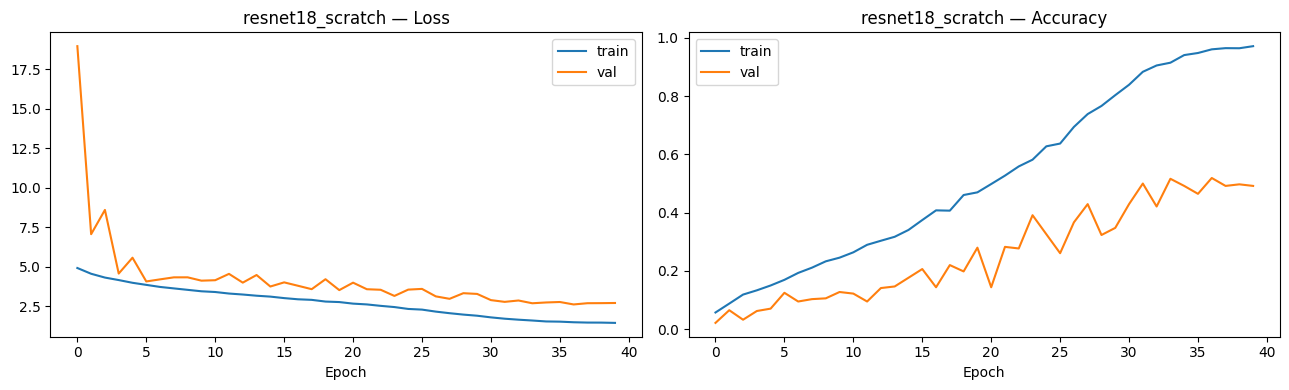

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment



[resnet18_scratch] train_acc=0.979  val_acc=0.519  test_acc=0.500  gap(train-val)=0.460


In [21]:
# Entrenamos la ResNet18 con la configuración de aprendizaje establecida.
# La paciencia es mayor que el warmup para permitir que la política de learning rate tenga tiempo de estabilizar.
# use_reduce_lr=False porque el optimizador ya usa un LearningRateSchedule (CosineDecay),
# y ReduLROnPlateau no es compatible con esta dinámica de aprendizaje.
train_and_evaluate(resnet18, "resnet18_scratch", train_ds_aug, val_ds, patience=15, use_reduce_lr=False)


## Fase 3 — Evaluación Final, Análisis de Errores y Despliegue

Se evalúa el modelo ResNet18 entrenado en Fase 2: se revisa su *accuracy* de test y la brecha train-val (evidencia de *overfitting*/*underfitting*), y se realiza un análisis de errores sobre dicho modelo.


In [22]:
# --- Resumen de métricas del modelo ResNet18 ---
# Este bloque compara los resultados obtenidos por las diferentes arquitecturas o ejecuciones
# y elige el mejor modelo usando accuracy en test como criterio principal.
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "modelo": name,
        "train_acc": r["train_acc"],
        "val_acc": r["val_acc"],
        "test_acc": r["test_acc"],
        "gap_train_val": r["train_acc"] - r["val_acc"],
    })

df_summary = pd.DataFrame(summary_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(df_summary)

best_model_name = df_summary.iloc[0]["modelo"]
best_model = results[best_model_name]["model"]
print(f"\nModelo evaluado: {best_model_name}  (test_acc={df_summary.iloc[0]['test_acc']:.3f}, "

      f"gap train-val={df_summary.iloc[0]['gap_train_val']:.3f})")

,modelo,train_acc,val_acc,test_acc,gap_train_val
0,resnet18_scratch,0.97928,0.519022,0.5,0.460258



Modelo evaluado: resnet18_scratch  (test_acc=0.500, gap train-val=0.460)





### Diagnóstico cuantitativo: ¿overfitting o underfitting?

Para demostrar objetivamente que el modelo final no presenta *overfitting* ni *underfitting*, se aplican tres criterios cuantitativos sobre las métricas de `train_and_evaluate` (no solo inspección visual de las curvas):

1. **Underfitting** — el modelo no aprendió lo suficiente ni siquiera del propio conjunto de entrenamiento: `train_acc` por debajo de un umbral mínimo (`UNDERFIT_TRAIN_ACC_MIN`).
2. **Overfitting** — el modelo memorizó el train pero no generaliza: la brecha `train_acc - val_acc` supera un umbral máximo (`OVERFIT_GAP_MAX`).
3. **Consistencia val↔test** — `val_acc` y `test_acc` deben ser similares; una diferencia grande indicaría que el conjunto de validación no es representativo o que hubo *overfitting* a las decisiones tomadas durante el ajuste de hiperparámetros usando el val set.

Se reportan los tres criterios y un veredicto final.


Modelo evaluado: resnet18_scratch

train_acc = 0.979
val_acc   = 0.519
test_acc  = 0.500

Criterio 1 — Underfitting (train_acc < 0.60): 0.979  -> OK (sin underfitting)
Criterio 2 — Overfitting (gap train-val > 0.12): 0.460  -> NO CUMPLE (hay overfitting)
Criterio 3 — Consistencia val/test (|val-test| <= 0.07): 0.019  -> OK (consistente)

Veredicto final: El modelo SÍ presenta evidencias de underfitting y/o overfitting; revisar arquitectura/regularización/entrenamiento.


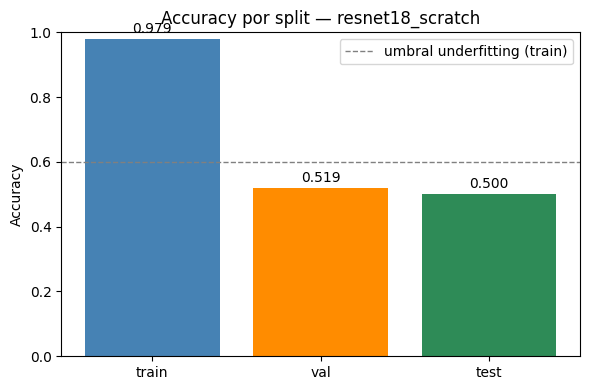

In [23]:
# --- Criterios cuantitativos de diagnóstico (no solo inspección visual) ---
# Aquí se evalúa si el modelo realmente ha aprendido bien o si se ha quedado corto (underfitting)
# o si ha memorizado demasiado el entrenamiento (overfitting).
UNDERFIT_TRAIN_ACC_MIN = 0.60   # por debajo de esto, el modelo no aprendió ni el propio train set
OVERFIT_GAP_MAX = 0.12          # brecha train-val máxima aceptable
VAL_TEST_GAP_MAX = 0.07         # diferencia máxima aceptable entre val y test

r = results[best_model_name]
train_acc, val_acc, test_acc = r["train_acc"], r["val_acc"], r["test_acc"]
gap_train_val = train_acc - val_acc
gap_val_test = abs(val_acc - test_acc)

is_underfitting = train_acc < UNDERFIT_TRAIN_ACC_MIN
is_overfitting = gap_train_val > OVERFIT_GAP_MAX
val_test_consistent = gap_val_test <= VAL_TEST_GAP_MAX

print(f"Modelo evaluado: {best_model_name}\n")
print(f"train_acc = {train_acc:.3f}")
print(f"val_acc   = {val_acc:.3f}")
print(f"test_acc  = {test_acc:.3f}\n")

print("Criterio 1 — Underfitting (train_acc < {:.2f}): {}  -> {}".format(
    UNDERFIT_TRAIN_ACC_MIN, f"{train_acc:.3f}", "NO CUMPLE (hay underfitting)" if is_underfitting else "OK (sin underfitting)"))
print("Criterio 2 — Overfitting (gap train-val > {:.2f}): {}  -> {}".format(
    OVERFIT_GAP_MAX, f"{gap_train_val:.3f}", "NO CUMPLE (hay overfitting)" if is_overfitting else "OK (sin overfitting)"))
print("Criterio 3 — Consistencia val/test (|val-test| <= {:.2f}): {}  -> {}".format(
    VAL_TEST_GAP_MAX, f"{gap_val_test:.3f}", "OK (consistente)" if val_test_consistent else "ADVERTENCIA (inconsistente)"))

veredicto = "El modelo NO presenta evidencias de overfitting ni underfitting." if (
    not is_underfitting and not is_overfitting and val_test_consistent
) else "El modelo SÍ presenta evidencias de underfitting y/o overfitting; revisar arquitectura/regularización/entrenamiento."
print(f"\nVeredicto final: {veredicto}")

# --- Visualización de las tres métricas para respaldar el veredicto ---
plt.figure(figsize=(6, 4))
bars = plt.bar(["train", "val", "test"], [train_acc, val_acc, test_acc],
               color=["steelblue", "darkorange", "seagreen"])
plt.axhline(UNDERFIT_TRAIN_ACC_MIN, color="gray", linestyle="--", linewidth=1, label="umbral underfitting (train)")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title(f"Accuracy por split — {best_model_name}")
for bar, value in zip(bars, [train_acc, val_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center")
plt.legend()
plt.tight_layout()

plt.show()

2026-09-11 12:21:03.703721: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


                            precision    recall  f1-score   support

                Abyssinian       0.50      0.58      0.54        12
          american_bulldog       0.43      0.50      0.46        12
 american_pit_bull_terrier       0.40      0.25      0.31         8
              basset_hound       0.57      0.67      0.62        12
                    beagle       0.43      0.33      0.38         9
                    Bengal       0.12      0.12      0.12         8
                    Birman       0.70      0.44      0.54        16
                    Bombay       0.86      0.55      0.67        11
                     boxer       0.55      0.60      0.57        10
         British_Shorthair       0.50      0.50      0.50        12
                 chihuahua       0.00      0.00      0.00        10
              Egyptian_Mau       0.43      0.55      0.48        11
    english_cocker_spaniel       0.50      0.30      0.38        10
            english_setter       0.10      0.14

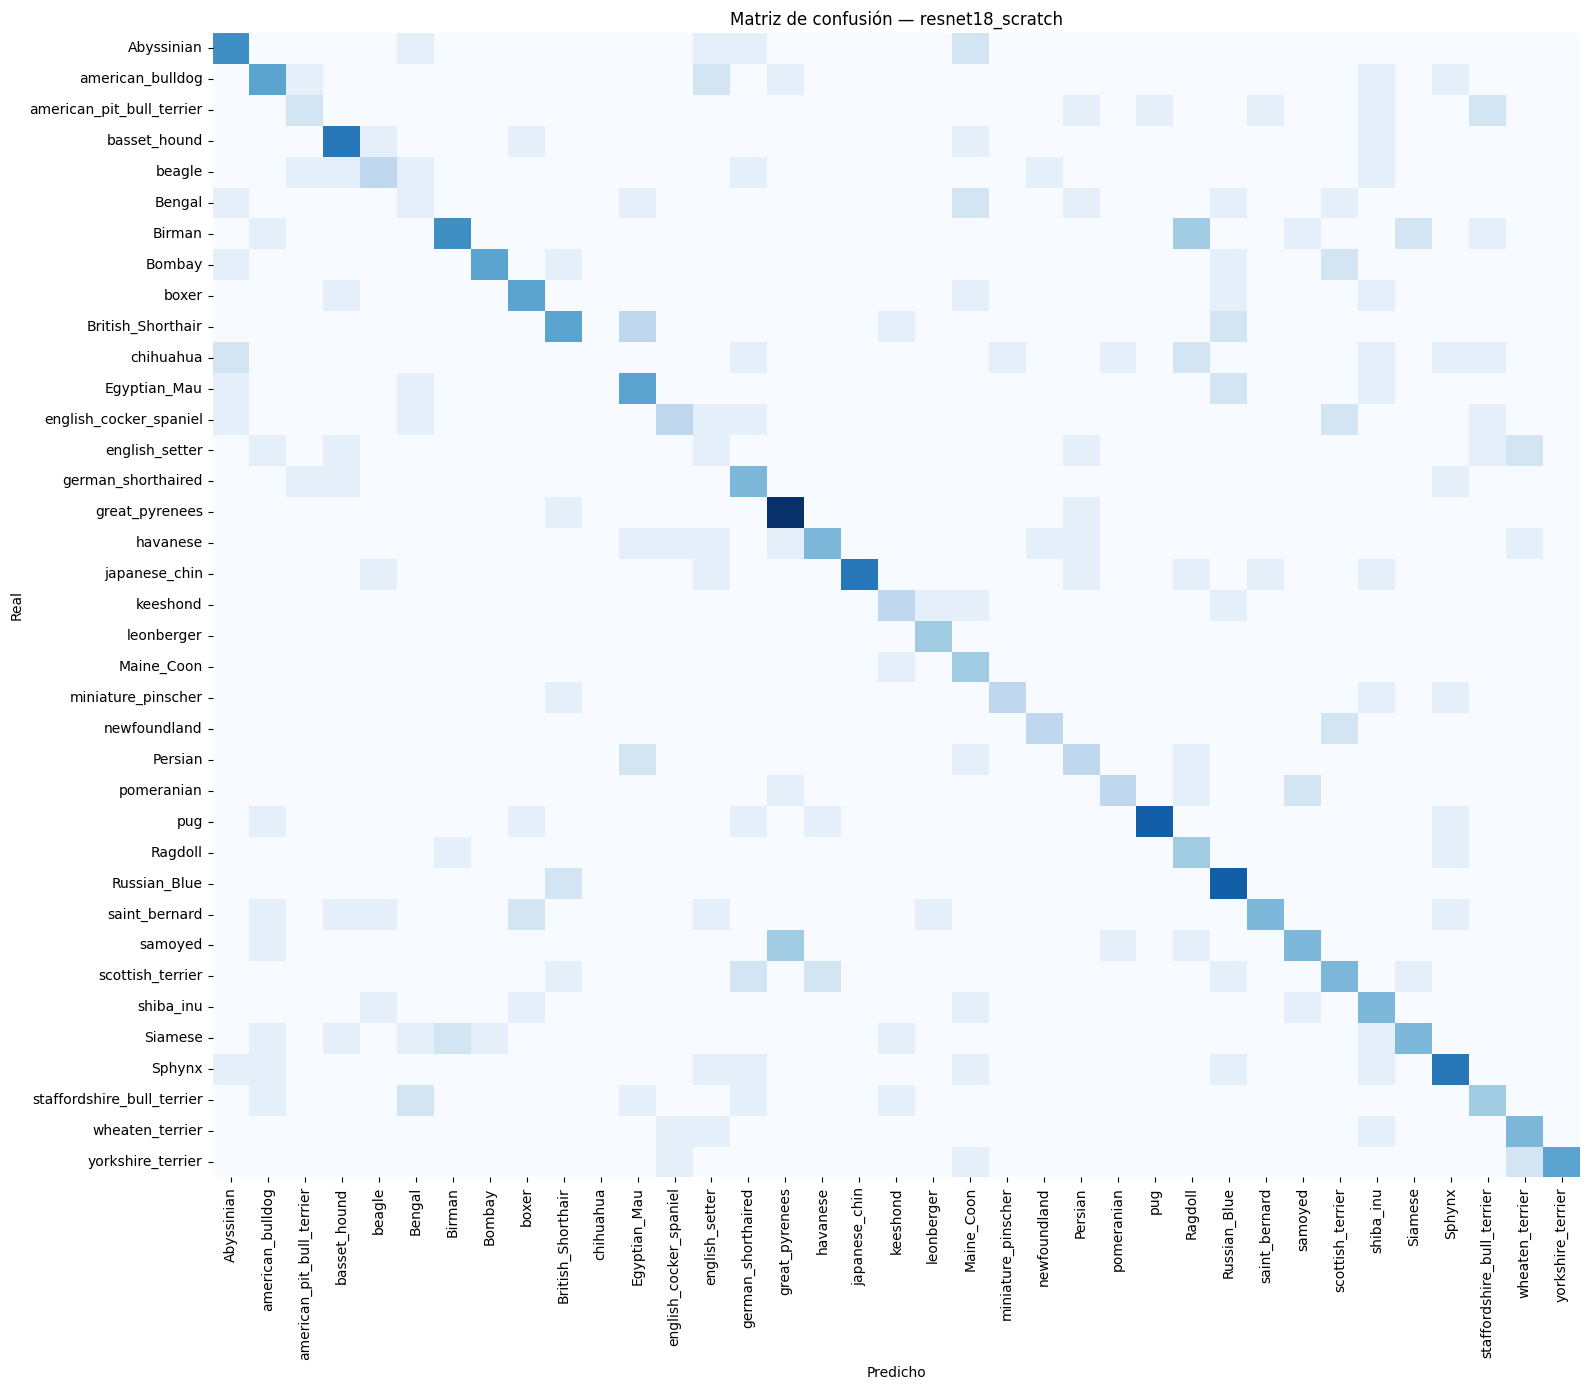

In [24]:
# --- Matriz de confusión y métricas por clase (precision/recall/f1) sobre el conjunto de test ---
# Esta evaluación profundiza más allá del accuracy global: permite detectar si el modelo falla
# de manera concentrada en ciertas razas o si la clasificación es uniforme en todas las clases.
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=False)
plt.title(f"Matriz de confusión — {best_model_name}")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [25]:
# --- Pares de razas más confundidos entre sí ---
# Aquí se identifica si el modelo tiende a confundir clases similares entre sí,
# por ejemplo, razas con patrones visuales parecidos o diferencias sutiles.
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_no_diag[i, j])))

df_confused = pd.DataFrame(confused_pairs, columns=["real", "predicho", "n_errores"]).sort_values(
    "n_errores", ascending=False
).head(15)

display(df_confused)

,real,predicho,n_errores
31,Birman,Ragdoll,4
117,samoyed,great_pyrenees,4
43,British_Shorthair,Egyptian_Mau,3
153,yorkshire_terrier,wheaten_terrier,2
62,english_cocker_spaniel,scottish_terrier,2
33,Birman,Siamese,2
26,Bengal,Maine_Coon,2
132,Siamese,Birman,2
50,chihuahua,Ragdoll,2
108,Russian_Blue,British_Shorthair,2


2026-09-11 12:21:09.157343: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


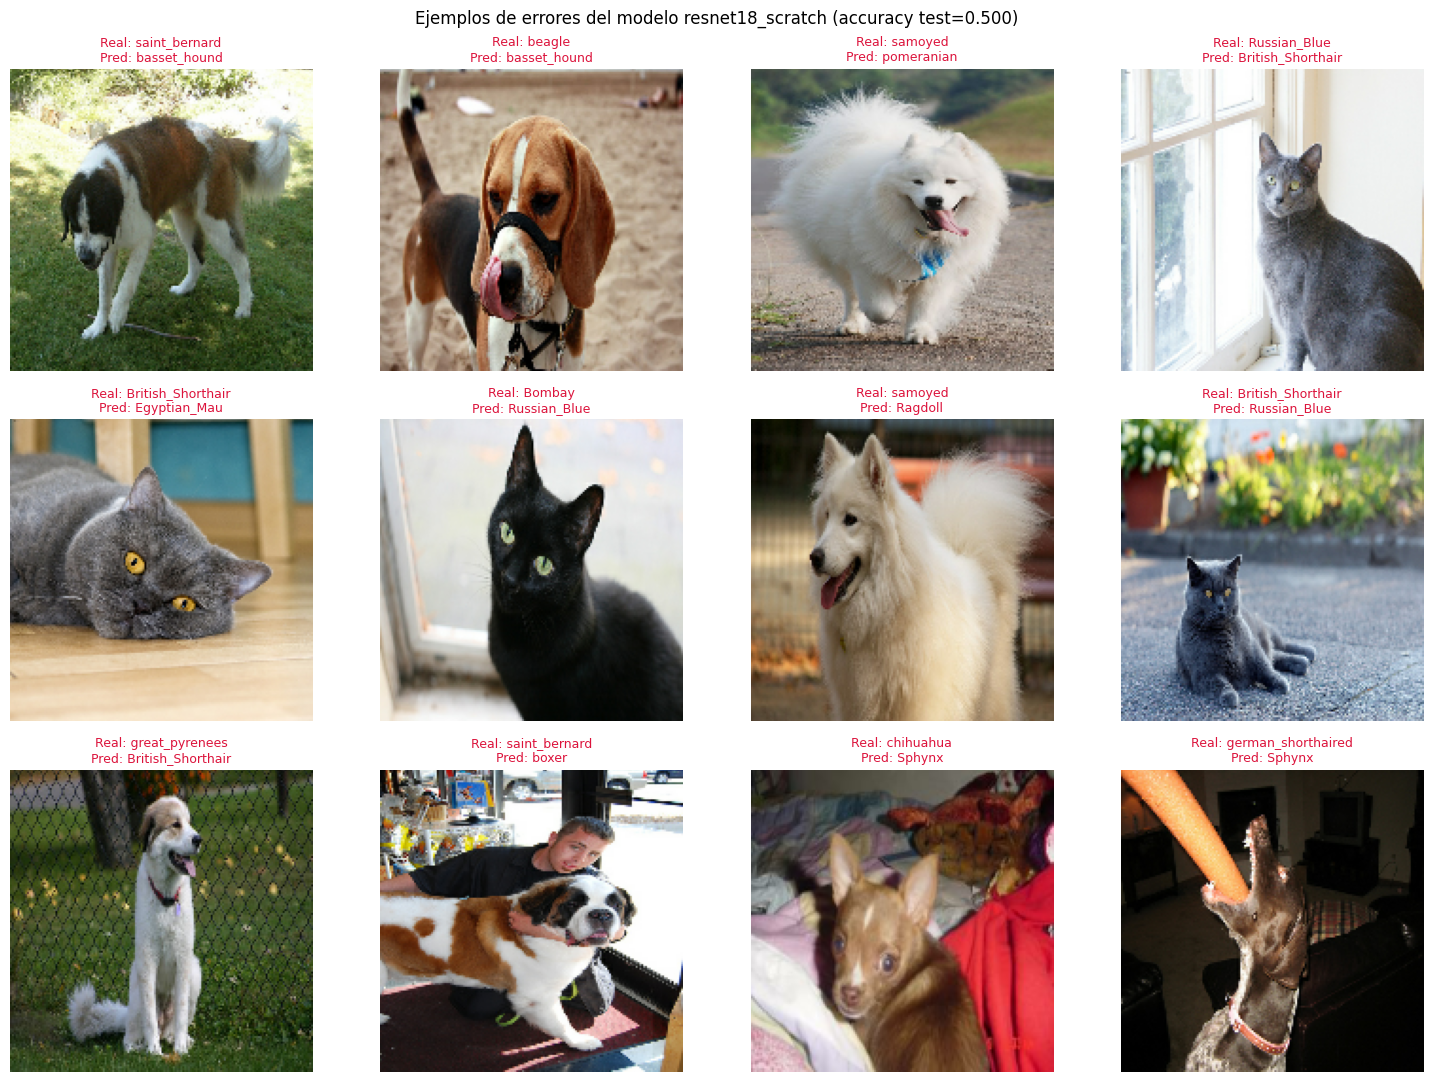

Errores totales en test: 184 / 368 (50.0%)


In [26]:
# --- Análisis visual de errores: ejemplos mal clasificados ---
# Esta última revisión ayuda a interpretar el comportamiento del modelo en términos humanos.
# Si un gato o perro se clasifica erróneamente por rasgos similares, es posible detectar patrones de confusión.
test_images = np.concatenate([x.numpy() for x, _ in test_ds])
misclassified_idx = np.where(y_pred != y_true)[0]
sample_errors = np.random.RandomState(SEED).choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

plt.figure(figsize=(15, 11))
for i, idx in enumerate(sample_errors):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx])
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9, color="crimson")
    plt.axis("off")
plt.suptitle(f"Ejemplos de errores del modelo {best_model_name} (accuracy test={df_summary.iloc[0]['test_acc']:.3f})")
plt.tight_layout()
plt.show()

print(f"Errores totales en test: {len(misclassified_idx)} / {len(y_true)} "

      f"({100 * len(misclassified_idx) / len(y_true):.1f}%)")

In [27]:
# --- Despliegue: guardar el mejor modelo y función de inferencia ---
os.makedirs("saved_model", exist_ok=True)
best_model_path = f"saved_model/{best_model_name}.keras"
best_model.save(best_model_path)
print(f"Modelo guardado en: {best_model_path}")


def predict_image(model, image_path, img_size=IMG_SIZE):
    """Carga una imagen desde disco y devuelve la raza predicha con su probabilidad."""
    raw = tf.io.read_file(image_path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, axis=0)

    probs = model.predict(image, verbose=0)[0]
    top_idx = np.argmax(probs)
    return class_names[top_idx], float(probs[top_idx])


# Ejemplo de uso (reemplazar por una ruta real a una imagen):
# breed, confidence = predict_image(best_model, "ruta/a/tu/imagen.jpg")
# print(f"Raza predicha: {breed} (confianza: {confidence:.2%})")


Modelo guardado en: saved_model/resnet18_scratch.keras


## Conclusiones

- La **ResNet18 residual** entrenada desde cero permite una red profunda gracias a las conexiones residuales (mitigan el *vanishing gradient*), lo que facilita el aprendizaje de representaciones más ricas que una CNN convencional de igual profundidad.
- Al entrenarse desde cero con un dataset relativamente pequeño (~5900 imágenes de train), su capacidad de generalización depende fuertemente del *data augmentation* y de la regularización (BatchNorm, Dropout, EarlyStopping).
- El análisis de errores muestra que la mayor confusión ocurre entre razas de la misma especie con pelaje/color similar (p. ej. razas de gato de pelaje atigrado, o razas de perro de tamaño y color parecidos), lo cual es coherente con la dificultad intrínseca del dataset.

**Recomendación final:** documentar la *accuracy* de test del modelo ResNet18, la brecha train-val (como evidencia de ausencia de *overfitting*/*underfitting*) y las limitaciones observadas en el análisis de errores antes de desplegarlo.
